In [ ]:
from datasets import load_dataset

dataset = load_dataset(
    "Exqrch/IndoDiscourse",
    "main"
)
main_df = dataset["main"].to_pandas()
print(main_df)

      text_id annotators_id  \
0         1-1       [7, 15]   
1        1-10       [7, 15]   
2       1-100       [7, 15]   
3      1-1000       [7, 15]   
4      1-1001      [10, 18]   
...       ...           ...   
28443   4-995          [19]   
28444   4-996          [19]   
28445   4-997          [19]   
28446   4-998          [19]   
28447   4-999          [19]   

                                                    text  \
0      Wajah Jurnalis Dibalut Perban Saat Melaporkan ...   
1      Elektabilitas Paslon 02 sebentar lagi terjun b...   
2      Gini aja deh @KPU_ID usul aja nih. Gimana kalo...   
3      Relawan Tionghoa Kalbar yg di Jakarta mendekla...   
4      Kristen, Hindu, Islam dapat perlakuan istimewa...   
...                                                  ...   
28443          Akun WhatsApp Pj Bupati Tegal Agustyarsah   
28444  Buldoser Israel Menabrak Pengungsi Pasien Ruma...   
28445  @TSolihien Sangat perlu di cek dan ricek kemba...   
28446  Perayaan Chinese New

In [ ]:
annotator_ds = load_dataset(
    "Exqrch/IndoDiscourse",
    "annotator"
)

annotator_df = annotator_ds["annotator"].to_pandas()

print(annotator_df)

    annotator_id ethnicity           religion disability lgbt gender  age  \
0              1  Tionghoa            Kristen         no   no      F   50   
1              2    Madura              Islam         no   no      F   22   
2              3     Batak  Kepercayaan Lokal         no   no      F   29   
3              4      Bali              Hindu         no   no      M   23   
4              5      Jawa              Syiah         no   no     M    46   
5              6    Minang          Ahmadiyah         no   no      F   22   
6              7    Minang              Islam        yes   no      F   27   
7              8      Arab              Islam         no   no      M   23   
8              9      Jawa              Islam         no   no      F   21   
9             10  Tionghoa             Buddha         no   no      F   20   
10            11     Bugis              Islam         no  yes      M   25   
11            12    Melayu              Islam         no   no      F   34   

In [ ]:
main_label = main_df.columns.tolist()

list_label = [
 'annotators_id',
 'is_noise_or_spam_text',
 'related_to_election_2024',
 'toxicity',
 'polarized',
 'profanity_obscenity',
 'threat_incitement_to_violence',
 'insults',
 'identity_attack',
 'sexually_explicit']

list_label

['annotators_id',
 'is_noise_or_spam_text',
 'related_to_election_2024',
 'toxicity',
 'polarized',
 'profanity_obscenity',
 'threat_incitement_to_violence',
 'insults',
 'identity_attack',
 'sexually_explicit']

In [ ]:
import ast

for col in list_label:
    main_df[col] = main_df[col].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x
    )

main_df

,text_id,annotators_id,text,initial_paragraph,topic,is_noise_or_spam_text,related_to_election_2024,toxicity,polarized,profanity_obscenity,threat_incitement_to_violence,insults,identity_attack,sexually_explicit
0,1-1,"[7, 15]",Wajah Jurnalis Dibalut Perban Saat Melaporkan ...,“️Jurnalis Hana Mahamed kembali tampil di tele...,UNKNOWN,"[0, 0]","[0, 0]","[0, 0]","[0, 0]","[0, 0]","[0, 0]","[0, 0]","[0, 0]","[0, 0]"
1,1-10,"[7, 15]",Elektabilitas Paslon 02 sebentar lagi terjun b...,None,Disabilitas,"[0, 0]","[1, 1]","[0, 0]","[1, 1]","[0, 0]","[0, 0]","[0, 0]","[0, 0]","[0, 0]"
2,1-100,"[7, 15]",Gini aja deh @KPU_ID usul aja nih. Gimana kalo...,None,Disabilitas,"[0, 0]","[1, 0]","[1, 0]","[0, 0]","[0, 0]","[0, 0]","[1, 0]","[0, 0]","[0, 0]"
3,1-1000,"[7, 15]",Relawan Tionghoa Kalbar yg di Jakarta mendekla...,None,Tionghoa,"[0, 0]","[1, 1]","[0, 0]","[1, 0]","[0, 0]","[0, 0]","[0, 0]","[0, 0]","[0, 0]"
4,1-1001,"[10, 18]","Kristen, Hindu, Islam dapat perlakuan istimewa...",None,Kristen,"[0, 0]","[1, 1]","[0, 0]","[1, 1]","[0, 0]","[0, 0]","[0, 0]","[0, 0]","[0, 0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28443,4-995,[19],Akun WhatsApp Pj Bupati Tegal Agustyarsah,“Assalamualaikum wr wb”,UNKNOWN,[0],[0],[0],[0],[0],[0],[0],[0],[0]
28444,4-996,[19],Buldoser Israel Menabrak Pengungsi Pasien Ruma...,“#GazaMassacre #Gaza Israeli bulldozers ran ov...,"Jewish, Rohingya",[0],[0],[0],[1],[0],[0],[0],[0],[0]
28445,4-997,[19],@TSolihien Sangat perlu di cek dan ricek kemba...,None,Rohingya,[1],[0],[0],[0],[0],[0],[0],[0],[0]
28446,4-998,[19],Perayaan Chinese New Year tahun ini ya akan ma...,None,Tionghoa,[0],[0],[0],[0],[0],[0],[0],[0],[0]


#Majority Voting Without metadata

In [ ]:
import pandas as pd

LABEL_COLS = [
    'toxicity',
    'is_noise_or_spam_text',
    'related_to_election_2024',
    'polarized',
    'profanity_obscenity',
    'threat_incitement_to_violence',
    'insults',
    'identity_attack',
    'sexually_explicit'
]

grouped = main_df.groupby("text")

results = []

for text, group in grouped:
    row_result = {"text": text}

    for col in LABEL_COLS:
        if col not in group.columns:
            continue

        votes = group[col].dropna().tolist()
        counts = pd.Series(votes).value_counts()

        # default
        status = "unknown"

        if len(counts) == 1:
            status = "full_agreement"
        elif len(counts) == 2:
            # contoh: 2 vs 2 (kalau annotator genap → rawan tie)
            if counts.iloc[0] == counts.iloc[1]:
                status = "tie_disagreement"
            else:
                status = "partial_disagreement"
        else:
            status = "high_disagreement"

        row_result[col] = status

    results.append(row_result)

agreement_df = pd.DataFrame(results)
agreement_df.head()

,text,toxicity,is_noise_or_spam_text,related_to_election_2024,polarized,profanity_obscenity,threat_incitement_to_violence,insults,identity_attack,sexually_explicit
0,"#NASIONAL Antisipasi Kekeringan, Bulog Akan I...",full_agreement,full_agreement,full_agreement,full_agreement,full_agreement,full_agreement,full_agreement,full_agreement,full_agreement
1,08 desember 2023 ODGJ DI SURABAYA DIPERBOLEHK...,full_agreement,full_agreement,full_agreement,full_agreement,full_agreement,full_agreement,full_agreement,full_agreement,full_agreement
2,2h ust. muflih kok gendutan skrg ya jgn jgn l...,full_agreement,full_agreement,full_agreement,full_agreement,full_agreement,full_agreement,full_agreement,full_agreement,full_agreement
3,CONFERENCIA DEPRENSA CASA GRANDE PUEBLO NPC B...,full_agreement,full_agreement,full_agreement,full_agreement,full_agreement,full_agreement,full_agreement,full_agreement,full_agreement
4,"DUH, KONDISI SERBA TERBATAS, KINI DAYA TAMPUN...",full_agreement,full_agreement,full_agreement,full_agreement,full_agreement,full_agreement,full_agreement,full_agreement,full_agreement


In [ ]:
summary = {}

for col in LABEL_COLS:
    summary[col] = agreement_df[col].value_counts()

summary_df = pd.DataFrame(summary).fillna(0)
summary_df

,toxicity,is_noise_or_spam_text,related_to_election_2024,polarized,profanity_obscenity,threat_incitement_to_violence,insults,identity_attack,sexually_explicit
full_agreement,24783,24735,24791,24662,24825,24829,24806,24803,24833
tie_disagreement,1266,1314,1258,1383,1224,1220,1243,1246,1216
high_disagreement,105,105,105,105,104,104,105,105,104
partial_disagreement,19,19,19,23,20,20,19,19,20


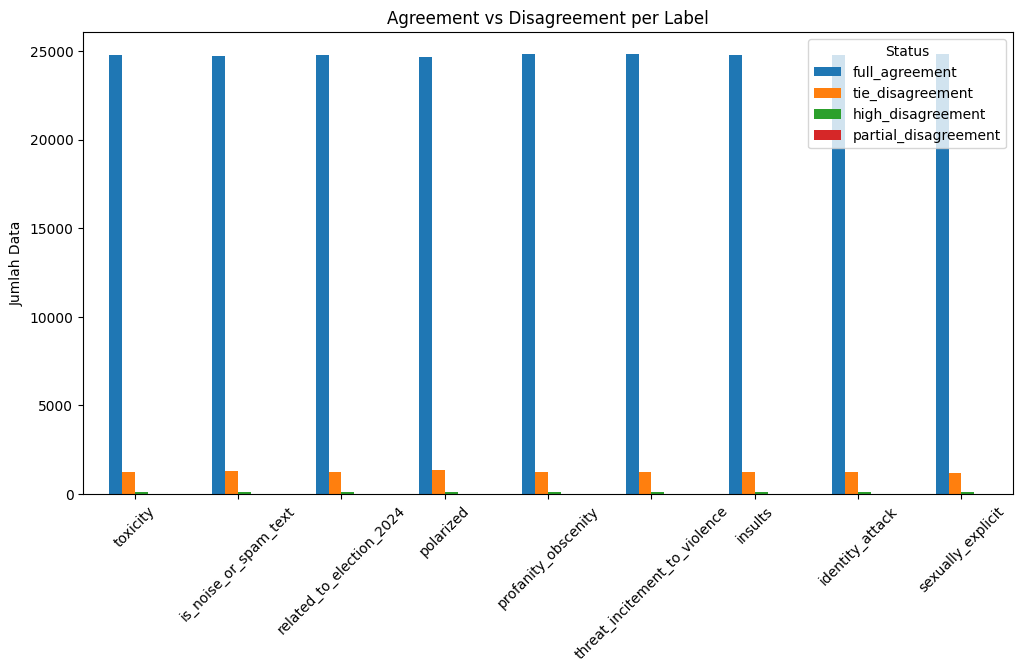

In [ ]:
import matplotlib.pyplot as plt

summary_df.T.plot(kind="bar", figsize=(12,6))

plt.title("Agreement vs Disagreement per Label")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=45)
plt.legend(title="Status")
plt.show()

In [ ]:
summary_df

,toxicity,is_noise_or_spam_text,related_to_election_2024,polarized,profanity_obscenity,threat_incitement_to_violence,insults,identity_attack,sexually_explicit
full_agreement,24783,24735,24791,24662,24825,24829,24806,24803,24833
tie_disagreement,1266,1314,1258,1383,1224,1220,1243,1246,1216
high_disagreement,105,105,105,105,104,104,105,105,104
partial_disagreement,19,19,19,23,20,20,19,19,20


In [ ]:
# ubah ke persentase per label
summary_pct = summary_df.div(summary_df.sum(axis=1), axis=0) * 100
summary_pct

,toxicity,is_noise_or_spam_text,related_to_election_2024,polarized,profanity_obscenity,threat_incitement_to_violence,insults,identity_attack,sexually_explicit
full_agreement,11.110115,11.088597,11.113701,11.055871,11.128943,11.130737,11.120426,11.119081,11.132530
tie_disagreement,11.134565,11.556728,11.064204,12.163588,10.765172,10.729991,10.932278,10.958663,10.694811
high_disagreement,11.146497,11.146497,11.146497,11.146497,11.040340,11.040340,11.146497,11.146497,11.040340
partial_disagreement,10.674157,10.674157,10.674157,12.921348,11.235955,11.235955,10.674157,10.674157,11.235955


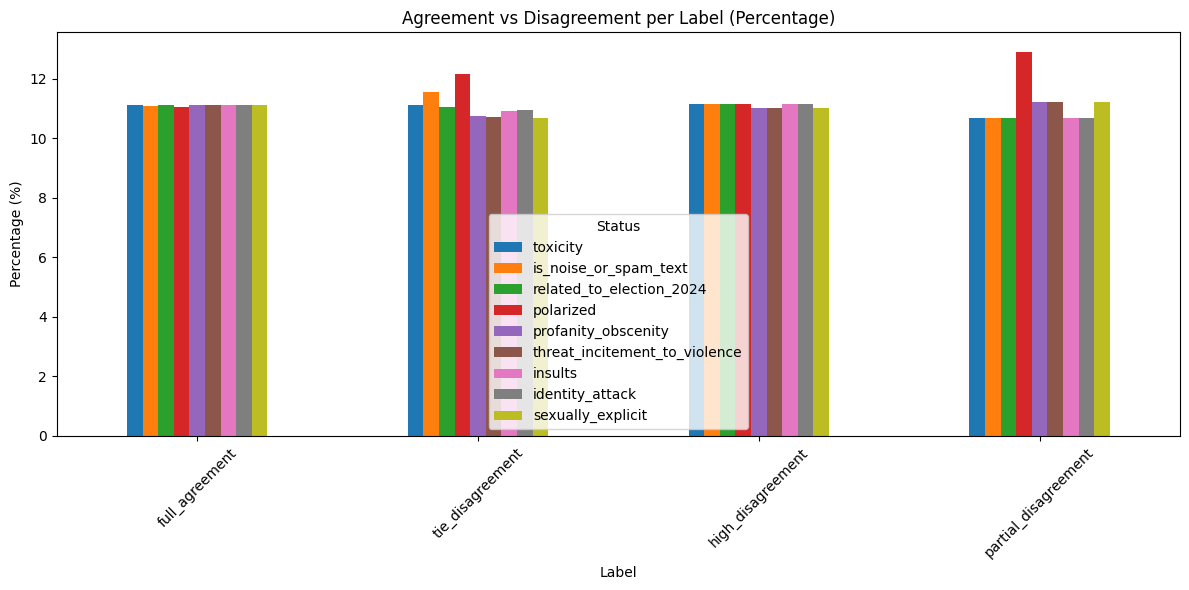

In [ ]:
import matplotlib.pyplot as plt

# ubah ke persentase per label
summary_pct = summary_df.div(summary_df.sum(axis=1), axis=0) * 100

ax = summary_pct.plot(kind="bar", figsize=(12,6))

plt.title("Agreement vs Disagreement per Label (Percentage)")
plt.ylabel("Percentage (%)")
plt.xlabel("Label")
plt.xticks(rotation=45)
plt.legend(title="Status")

plt.tight_layout()
plt.show()

In [ ]:
tie_cases = agreement_df[
    agreement_df[LABEL_COLS].apply(lambda x: "tie_disagreement" in x.values, axis=1)
]

tie_cases.head()

,text,toxicity,is_noise_or_spam_text,related_to_election_2024,polarized,profanity_obscenity,threat_incitement_to_violence,insults,identity_attack,sexually_explicit
29,""" Banyak orang menginginkan perubahan dalam hi...",tie_disagreement,tie_disagreement,tie_disagreement,tie_disagreement,tie_disagreement,tie_disagreement,tie_disagreement,tie_disagreement,tie_disagreement
44,"""Berpura-pura gila agar menjadi tidak gila.""",tie_disagreement,tie_disagreement,tie_disagreement,tie_disagreement,tie_disagreement,tie_disagreement,tie_disagreement,tie_disagreement,tie_disagreement
50,"""Capresnya Milenial dan Gen Z! Ganjar Pranowo ...",tie_disagreement,tie_disagreement,tie_disagreement,tie_disagreement,tie_disagreement,tie_disagreement,tie_disagreement,tie_disagreement,tie_disagreement
91,"""Lu udah ngga minum itu obat?"" Diusahain udah ...",tie_disagreement,tie_disagreement,tie_disagreement,tie_disagreement,tie_disagreement,tie_disagreement,tie_disagreement,tie_disagreement,tie_disagreement
101,"""No climate justice on occupied land"" Seorang ...",tie_disagreement,tie_disagreement,tie_disagreement,tie_disagreement,tie_disagreement,tie_disagreement,tie_disagreement,tie_disagreement,tie_disagreement


In [ ]:
import numpy as np
import pandas as pd
from collections import Counter

def majority_vote(cell):
    if isinstance(cell, (list, np.ndarray)):
        vals = [int(x) for x in cell]
        counts = Counter(vals)

        # kalau semua sama (full agreement)
        if len(counts) == 1:
            return vals[0]

        # kalau tie (contoh [0,1] atau [1,0])
        if len(set(counts.values())) == 1:
            return None  # tie → buang

        # majority vote
        return counts.most_common(1)[0][0]

    return int(cell)

In [ ]:
df = main_df.copy()

for col in LABEL_COLS:
    df[col] = df[col].apply(majority_vote)

In [ ]:
clean_df = df.dropna(subset=LABEL_COLS)

In [ ]:
long_df = clean_df.melt(
    id_vars=["text"],
    value_vars=LABEL_COLS,
    var_name="label",
    value_name="value"
)
long_df["value"] = long_df["value"].astype(int)

In [ ]:
dist = long_df.groupby(["label", "value"]).size().unstack(fill_value=0)
dist

value,0,1
label,,
identity_attack,22938,613
insults,22961,590
is_noise_or_spam_text,22191,1360
polarized,20317,3234
profanity_obscenity,23347,204
related_to_election_2024,22093,1458
sexually_explicit,23514,37
threat_incitement_to_violence,23476,75
toxicity,22099,1452


In [ ]:
tox_df = long_df[long_df["label"] == "toxicity"].copy()

dist_tox = tox_df.groupby("value").size().reindex([0,1], fill_value=0)
dist_tox

dist_tox.index = dist_tox.index.map({0: "non-toxic", 1: "toxic"})

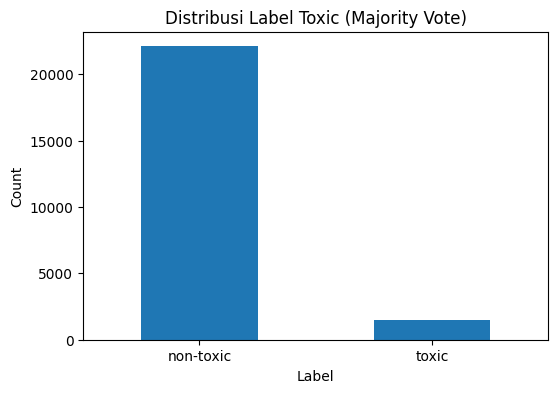

In [ ]:
plt.figure(figsize=(6,4))
dist_tox.plot(kind="bar")

plt.title("Distribusi Label Toxic (Majority Vote)")
plt.ylabel("Count")
plt.xlabel("Label")
plt.xticks(rotation=0)

plt.show()

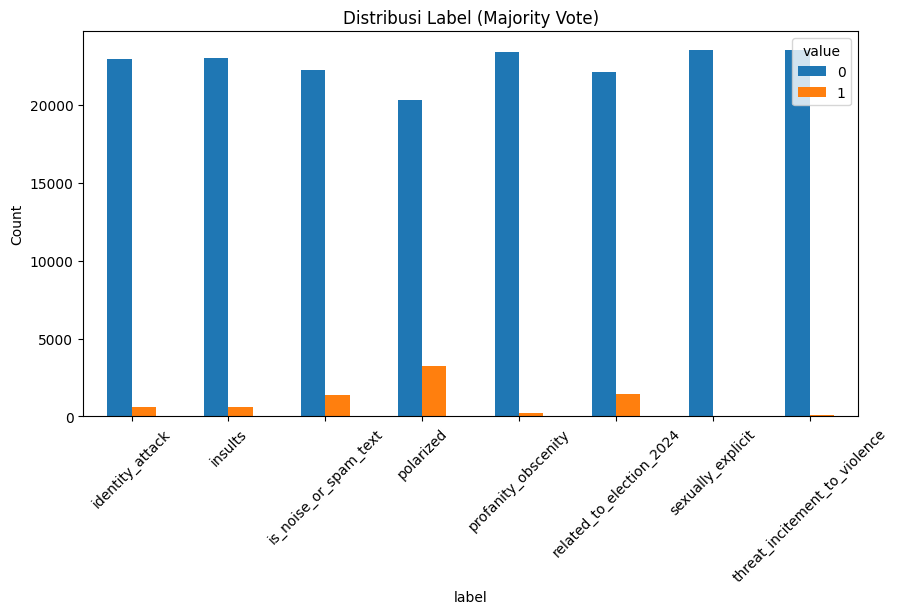

In [ ]:
import matplotlib.pyplot as plt

dist_no_tox = dist.drop(index="toxicity")

dist_no_tox.plot(kind="bar", figsize=(10,5))
plt.title("Distribusi Label (Majority Vote)")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

#Explosion Data Metadata

In [ ]:
exp_data = main_df.explode(list_label)
exp_data = exp_data.rename(
    columns={"annotators_id": "annotator_id"}
)
exp_data

,text_id,annotator_id,text,initial_paragraph,topic,is_noise_or_spam_text,related_to_election_2024,toxicity,polarized,profanity_obscenity,threat_incitement_to_violence,insults,identity_attack,sexually_explicit
0,1-1,7,Wajah Jurnalis Dibalut Perban Saat Melaporkan ...,“️Jurnalis Hana Mahamed kembali tampil di tele...,UNKNOWN,0,0,0,0,0,0,0,0,0
0,1-1,15,Wajah Jurnalis Dibalut Perban Saat Melaporkan ...,“️Jurnalis Hana Mahamed kembali tampil di tele...,UNKNOWN,0,0,0,0,0,0,0,0,0
1,1-10,7,Elektabilitas Paslon 02 sebentar lagi terjun b...,None,Disabilitas,0,1,0,1,0,0,0,0,0
1,1-10,15,Elektabilitas Paslon 02 sebentar lagi terjun b...,None,Disabilitas,0,1,0,1,0,0,0,0,0
2,1-100,7,Gini aja deh @KPU_ID usul aja nih. Gimana kalo...,None,Disabilitas,0,1,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28443,4-995,19,Akun WhatsApp Pj Bupati Tegal Agustyarsah,“Assalamualaikum wr wb”,UNKNOWN,0,0,0,0,0,0,0,0,0
28444,4-996,19,Buldoser Israel Menabrak Pengungsi Pasien Ruma...,“#GazaMassacre #Gaza Israeli bulldozers ran ov...,"Jewish, Rohingya",0,0,0,1,0,0,0,0,0
28445,4-997,19,@TSolihien Sangat perlu di cek dan ricek kemba...,None,Rohingya,1,0,0,0,0,0,0,0,0
28446,4-998,19,Perayaan Chinese New Year tahun ini ya akan ma...,None,Tionghoa,0,0,0,0,0,0,0,0,0


In [ ]:
exp_data["annotator_id"] = exp_data["annotator_id"].astype(str)
annotator_df["annotator_id"] = annotator_df["annotator_id"].astype(str)

merged_df = exp_data.merge(
    annotator_df,
    on="annotator_id",
    how="left"
)

merged_df



,text_id,annotator_id,text,initial_paragraph,topic,is_noise_or_spam_text,related_to_election_2024,toxicity,polarized,profanity_obscenity,...,ethnicity,religion,disability,lgbt,gender,age,domisili,pendidikan terakhir,status pekerjaan,president vote leaning
0,1-1,7,Wajah Jurnalis Dibalut Perban Saat Melaporkan ...,“️Jurnalis Hana Mahamed kembali tampil di tele...,UNKNOWN,0,0,0,0,0,...,Minang,Islam,yes,no,F,27,Padang,Sarjana (S1),Bekerja,1
1,1-1,15,Wajah Jurnalis Dibalut Perban Saat Melaporkan ...,“️Jurnalis Hana Mahamed kembali tampil di tele...,UNKNOWN,0,0,0,0,0,...,Tionghoa,Katolik,yes,no,F,21,Jakarta,Sekolah Menengah Atas (SMA),Pelajar/Mahasiswa,3
2,1-10,7,Elektabilitas Paslon 02 sebentar lagi terjun b...,None,Disabilitas,0,1,0,1,0,...,Minang,Islam,yes,no,F,27,Padang,Sarjana (S1),Bekerja,1
3,1-10,15,Elektabilitas Paslon 02 sebentar lagi terjun b...,None,Disabilitas,0,1,0,1,0,...,Tionghoa,Katolik,yes,no,F,21,Jakarta,Sekolah Menengah Atas (SMA),Pelajar/Mahasiswa,3
4,1-100,7,Gini aja deh @KPU_ID usul aja nih. Gimana kalo...,None,Disabilitas,0,1,1,0,0,...,Minang,Islam,yes,no,F,27,Padang,Sarjana (S1),Bekerja,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53655,4-995,19,Akun WhatsApp Pj Bupati Tegal Agustyarsah,“Assalamualaikum wr wb”,UNKNOWN,0,0,0,0,0,...,Batak,Kristen,no,no,F,39,Depok,Magister (S2),Bekerja,2
53656,4-996,19,Buldoser Israel Menabrak Pengungsi Pasien Ruma...,“#GazaMassacre #Gaza Israeli bulldozers ran ov...,"Jewish, Rohingya",0,0,0,1,0,...,Batak,Kristen,no,no,F,39,Depok,Magister (S2),Bekerja,2
53657,4-997,19,@TSolihien Sangat perlu di cek dan ricek kemba...,None,Rohingya,1,0,0,0,0,...,Batak,Kristen,no,no,F,39,Depok,Magister (S2),Bekerja,2
53658,4-998,19,Perayaan Chinese New Year tahun ini ya akan ma...,None,Tionghoa,0,0,0,0,0,...,Batak,Kristen,no,no,F,39,Depok,Magister (S2),Bekerja,2


In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

/tmp/ipykernel_4595/1200942754.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  non_toxic_count = tox_dist[0]
/tmp/ipykernel_4595/1200942754.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  toxic_count = tox_dist[1]


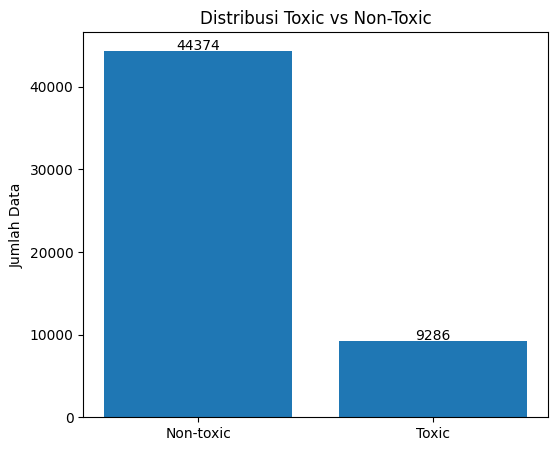

In [ ]:
tox_dist = merged_df["toxicity"].value_counts()

non_toxic_count = tox_dist[0]
toxic_count = tox_dist[1]

plt.figure(figsize=(6,5))

plt.bar(
    ["Non-toxic", "Toxic"],
    [non_toxic_count, toxic_count]
)

plt.title("Distribusi Toxic vs Non-Toxic")
plt.ylabel("Jumlah Data")

for i, v in enumerate([
    non_toxic_count,
    toxic_count
]):
    plt.text(i, v + 50, str(v), ha='center')

plt.show()

In [ ]:
LABEL_STAGE1_COLS = [
 'is_noise_or_spam_text',
 'related_to_election_2024',
 'polarized',
 'profanity_obscenity',
 'threat_incitement_to_violence',
 'insults',
 'identity_attack',
 'sexually_explicit']

In [ ]:
for col in LABEL_STAGE1_COLS:
    merged_df[col] = merged_df[col].astype(int)


In [ ]:
label_counts = {}

for col in LABEL_STAGE1_COLS:

    label_counts[col] = merged_df[col].sum()

label_counts

{'is_noise_or_spam_text': np.int64(3428),
 'related_to_election_2024': np.int64(5545),
 'polarized': np.int64(11540),
 'profanity_obscenity': np.int64(1739),
 'threat_incitement_to_violence': np.int64(1728),
 'insults': np.int64(4311),
 'identity_attack': np.int64(4263),
 'sexually_explicit': np.int64(400)}

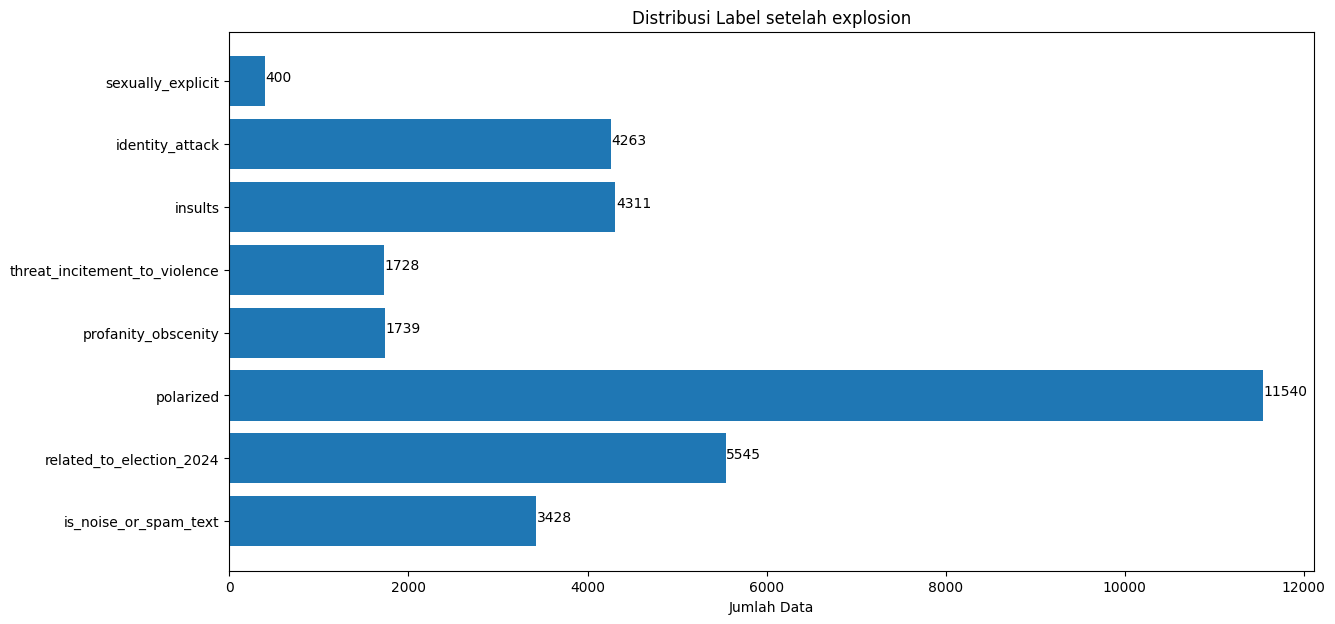

In [ ]:
import matplotlib.pyplot as plt

labels = list(label_counts.keys())
values = list(label_counts.values())

plt.figure(figsize=(14,7))

plt.barh(labels, values)

plt.title(
    "Distribusi Label setelah explosion"
)

plt.xlabel("Jumlah Data")

for i, v in enumerate(values):
    plt.text(v + 5, i, str(v))

plt.show()

In [ ]:
metadata_cols = annotator_df.columns.tolist()
metadata_cols.remove('annotator_id')
print(metadata_cols)

['ethnicity', 'religion', 'disability', 'lgbt', 'gender', 'age', 'domisili', 'pendidikan terakhir', 'status pekerjaan', 'president vote leaning']


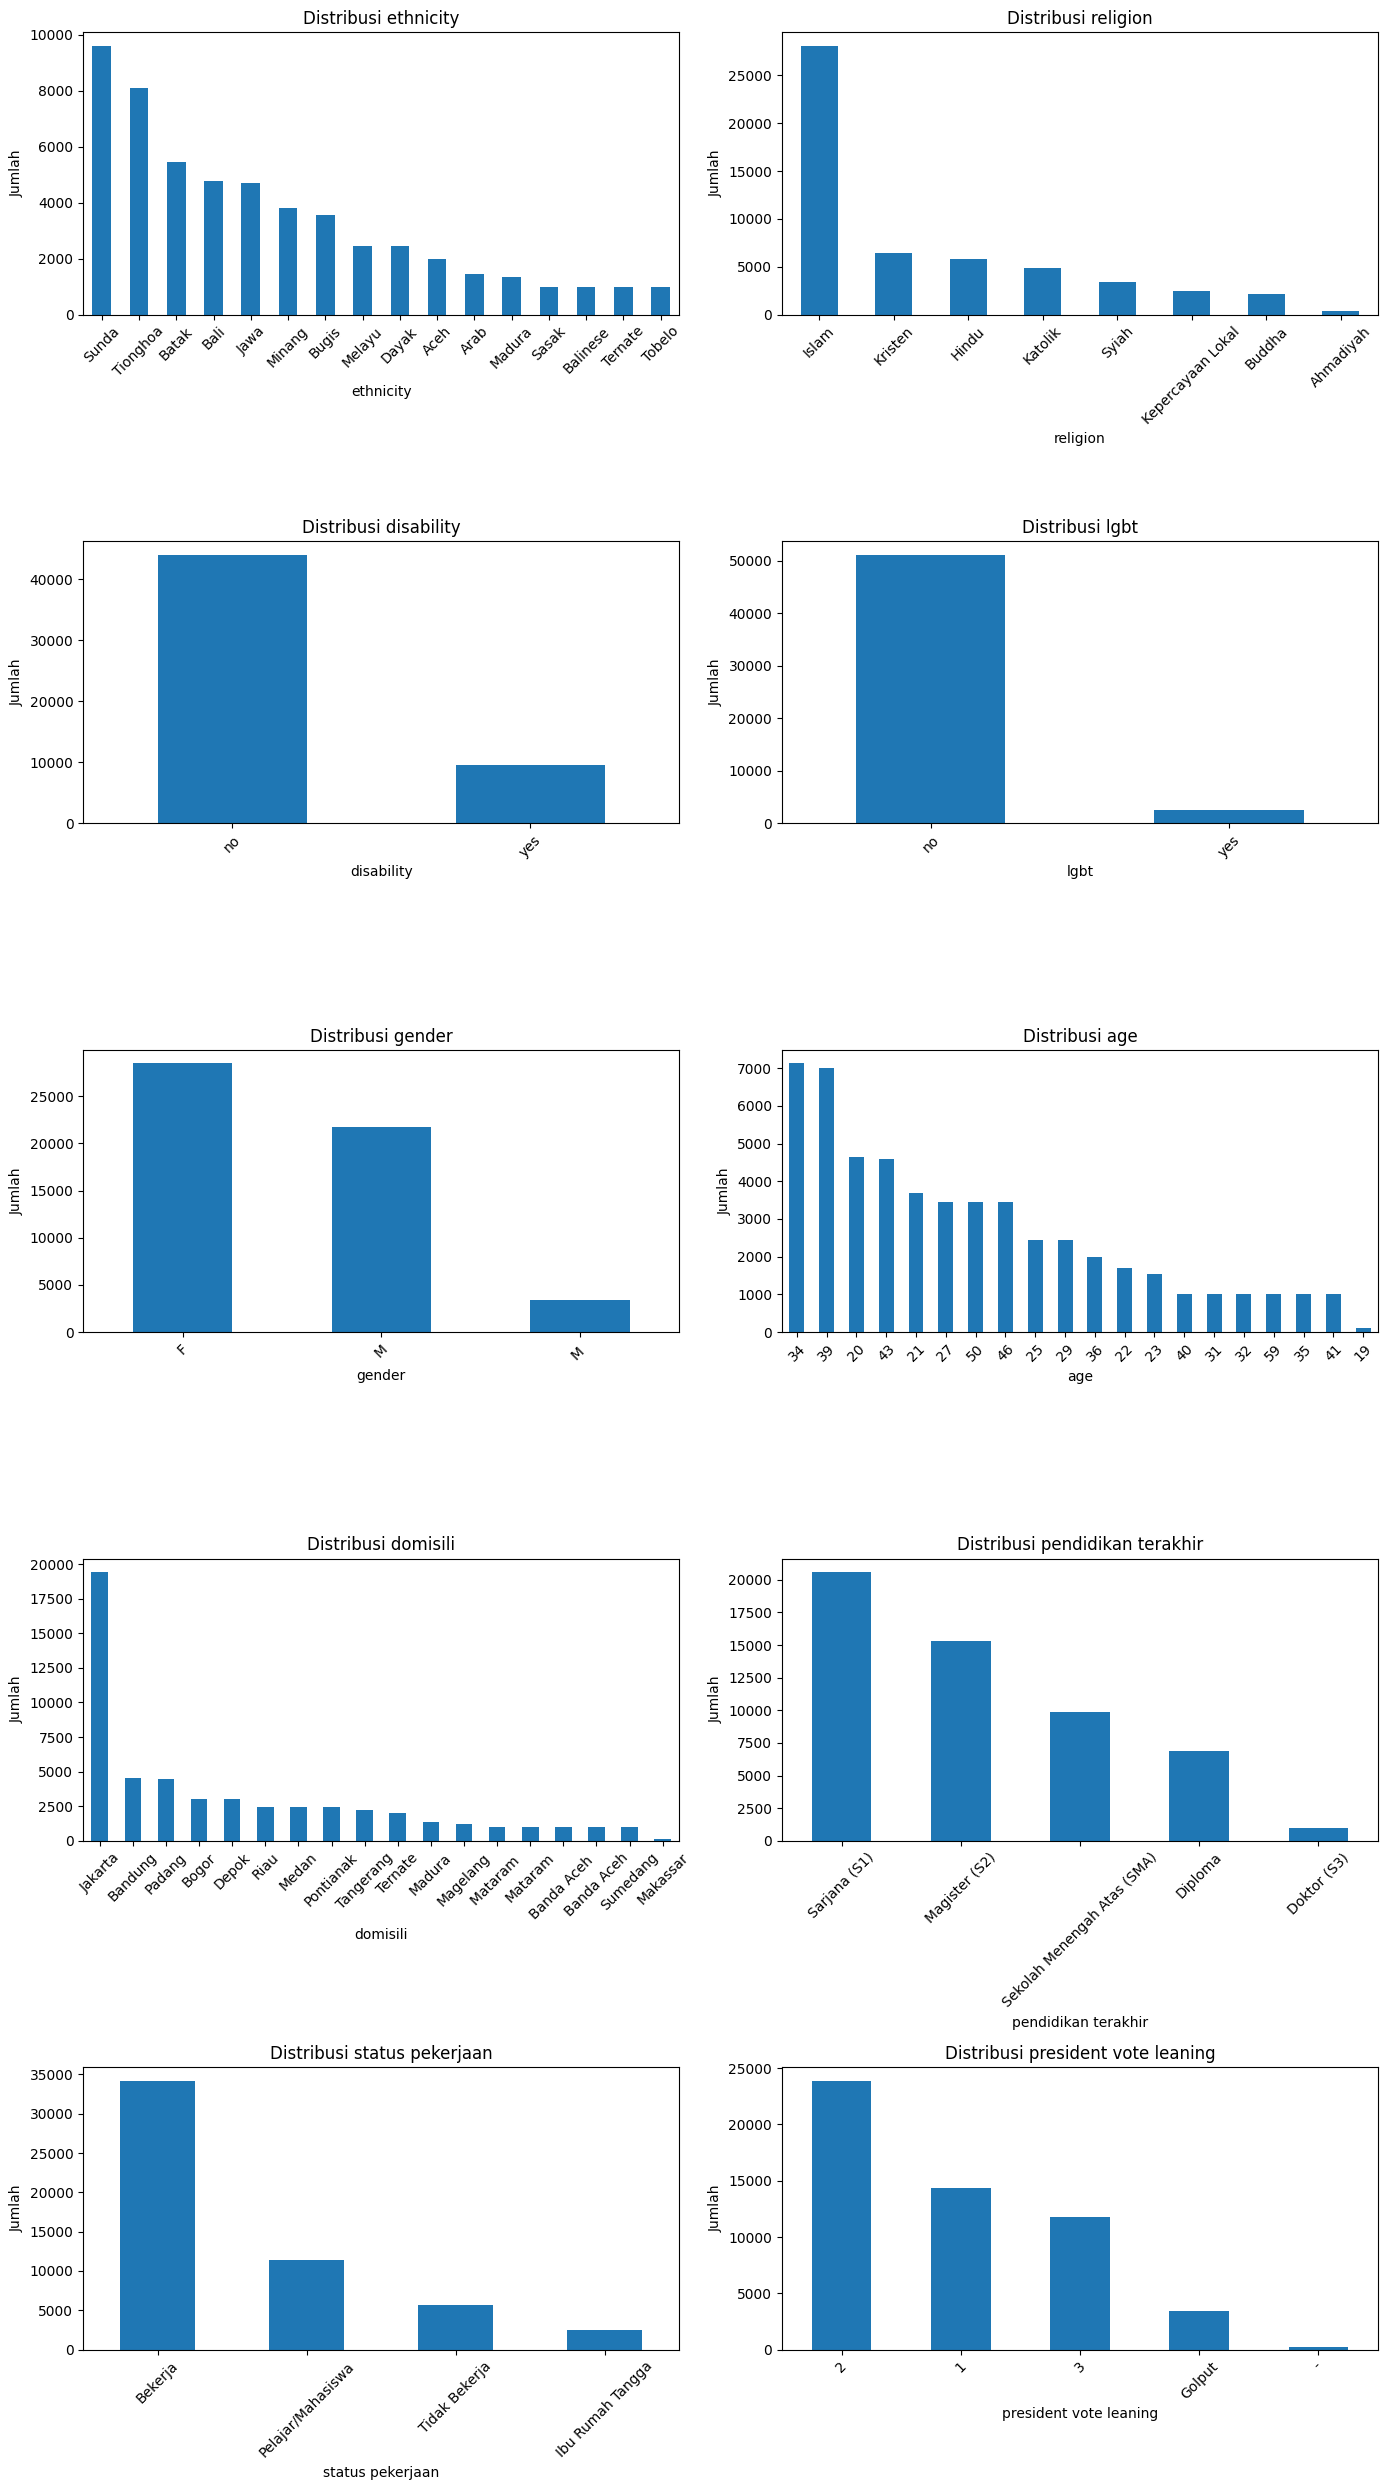

In [ ]:
import matplotlib.pyplot as plt
import math

n_cols = 2
n_rows = math.ceil(len(metadata_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))

axes = axes.flatten()  # supaya gampang di-loop

for i, col in enumerate(metadata_cols):
    merged_df[col].value_counts().plot(
        kind="bar",
        ax=axes[i]
    )

    axes[i].set_title(f"Distribusi {col}")
    axes[i].set_ylabel("Jumlah")
    axes[i].tick_params(axis='x', rotation=45)

# hapus subplot kosong kalau jumlah kolom ganjil
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

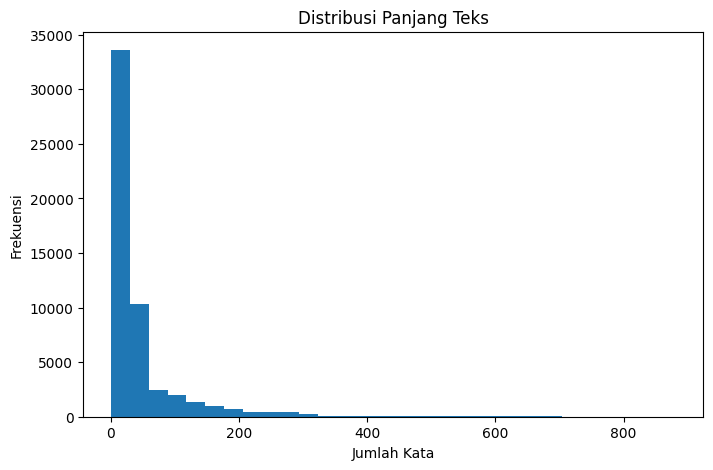

In [ ]:
merged_df["text_length"] = (
    merged_df["text"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

plt.figure(figsize=(8,5))

plt.hist(
    merged_df["text_length"],
    bins=30
)

plt.title("Distribusi Panjang Teks")
plt.xlabel("Jumlah Kata")
plt.ylabel("Frekuensi")

plt.show()

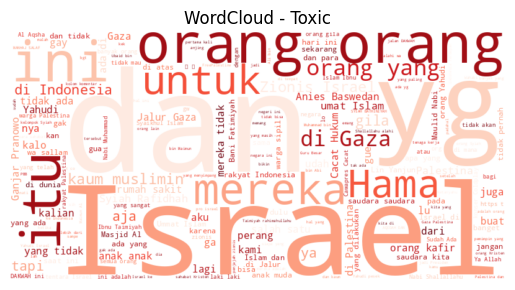

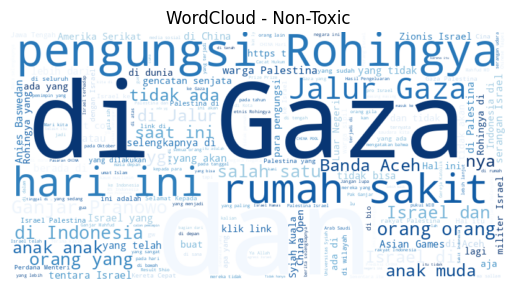

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# sesuaikan kalau label kamu beda (misalnya "toxic" / "non-toxic")
toxic_text = " ".join(merged_df[merged_df["toxicity"] == "1"]["text"].astype(str))
non_toxic_text = " ".join(merged_df[merged_df["toxicity"] == "0"]["text"].astype(str))

wordcloud_toxic = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="Reds"
).generate(toxic_text)

wordcloud_non_toxic = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="Blues"
).generate(non_toxic_text)


# plt.subplot(1,2,1)
plt.imshow(wordcloud_toxic, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud - Toxic")
plt.show()

# plt.subplot(1,2,2)
plt.imshow(wordcloud_non_toxic, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud - Non-Toxic")

plt.show()

In [ ]:
annotator_cols = annotator_df.columns.to_list()
annotator_cols.remove('annotator_id')
annotator_cols

['ethnicity',
 'religion',
 'disability',
 'lgbt',
 'gender',
 'age',
 'domisili',
 'pendidikan terakhir',
 'status pekerjaan',
 'president vote leaning']

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_temp = merged_df.copy()

for col in annotator_cols:
    df_temp[col] = df_temp[col].astype(str)
    df_temp[col] = LabelEncoder().fit_transform(df_temp[col])

df_temp

,text_id,annotator_id,text,initial_paragraph,topic,is_noise_or_spam_text,related_to_election_2024,toxicity,polarized,profanity_obscenity,...,religion,disability,lgbt,gender,age,domisili,pendidikan terakhir,status pekerjaan,president vote leaning,text_length
0,1-1,7,Wajah Jurnalis Dibalut Perban Saat Melaporkan ...,“️Jurnalis Hana Mahamed kembali tampil di tele...,UNKNOWN,0,0,0,0,0,...,3,1,0,0,6,12,3,0,1,10
1,1-1,15,Wajah Jurnalis Dibalut Perban Saat Melaporkan ...,“️Jurnalis Hana Mahamed kembali tampil di tele...,UNKNOWN,0,0,0,0,0,...,4,1,0,0,2,5,4,2,3,10
2,1-10,7,Elektabilitas Paslon 02 sebentar lagi terjun b...,None,Disabilitas,0,1,0,1,0,...,3,1,0,0,6,12,3,0,1,22
3,1-10,15,Elektabilitas Paslon 02 sebentar lagi terjun b...,None,Disabilitas,0,1,0,1,0,...,4,1,0,0,2,5,4,2,3,22
4,1-100,7,Gini aja deh @KPU_ID usul aja nih. Gimana kalo...,None,Disabilitas,0,1,1,0,0,...,3,1,0,0,6,12,3,0,1,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53655,4-995,19,Akun WhatsApp Pj Bupati Tegal Agustyarsah,“Assalamualaikum wr wb”,UNKNOWN,0,0,0,0,0,...,6,0,0,0,13,4,2,0,2,6
53656,4-996,19,Buldoser Israel Menabrak Pengungsi Pasien Ruma...,“#GazaMassacre #Gaza Israeli bulldozers ran ov...,"Jewish, Rohingya",0,0,0,1,0,...,6,0,0,0,13,4,2,0,2,11
53657,4-997,19,@TSolihien Sangat perlu di cek dan ricek kemba...,None,Rohingya,1,0,0,0,0,...,6,0,0,0,13,4,2,0,2,21
53658,4-998,19,Perayaan Chinese New Year tahun ini ya akan ma...,None,Tionghoa,0,0,0,0,0,...,6,0,0,0,13,4,2,0,2,230


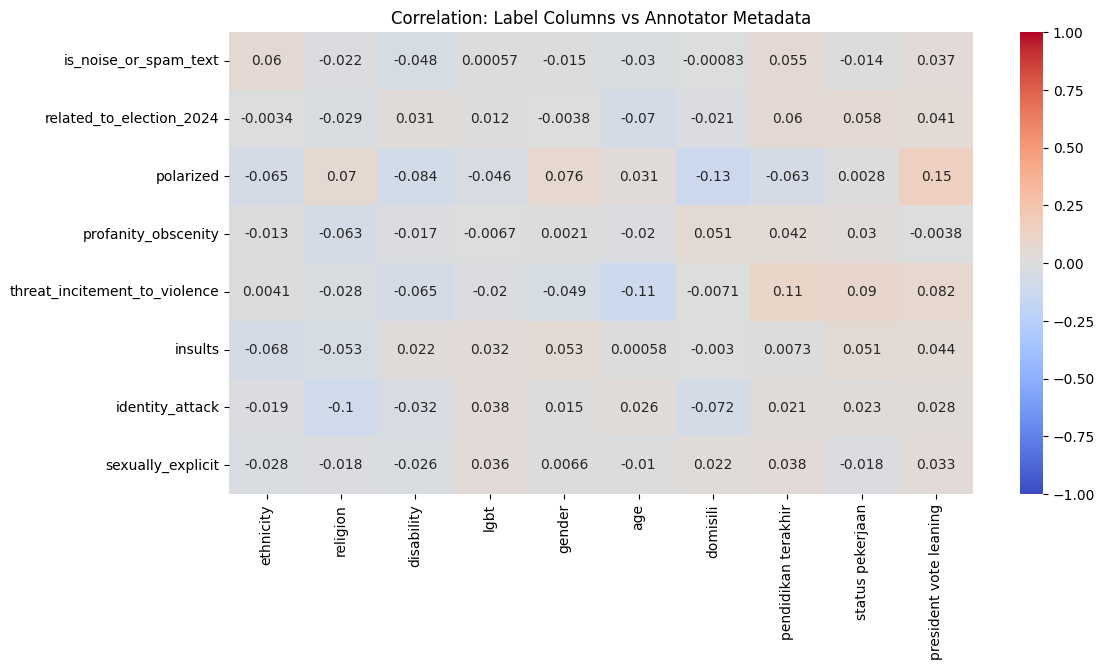

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

label_cols = [
 'is_noise_or_spam_text',
 'related_to_election_2024',
 'polarized',
 'profanity_obscenity',
 'threat_incitement_to_violence',
 'insults',
 'identity_attack',
 'sexually_explicit']

# correlation matrix full
corr = df_temp[label_cols + annotator_cols].corr(numeric_only=True)

# ambil hanya: label vs annotator
corr_subset = corr.loc[label_cols, annotator_cols]

plt.figure(figsize=(12, 6))

sns.heatmap(
    corr_subset,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation: Label Columns vs Annotator Metadata")
plt.show()

###Stage 2

In [ ]:
stage2_df = merged_df[
    merged_df["toxicity"] == "1"
]
stage2_df

,text_id,annotator_id,text,initial_paragraph,topic,is_noise_or_spam_text,related_to_election_2024,toxicity,polarized,profanity_obscenity,...,religion,disability,lgbt,gender,age,domisili,pendidikan terakhir,status pekerjaan,president vote leaning,text_length
4,1-100,7,Gini aja deh @KPU_ID usul aja nih. Gimana kalo...,None,Disabilitas,0,1,1,0,0,...,Islam,yes,no,F,27,Padang,Sarjana (S1),Bekerja,1,39
26,1-101,7,"Apakah kita harus di pimpin oleh orang yg,waki...",None,Disabilitas,0,1,1,0,0,...,Islam,yes,no,F,27,Padang,Sarjana (S1),Bekerja,1,15
37,1-1014,18,Video Wanita Muslim Memaksa Wanita Hindu untuk...,"""Wanita Islam melecehkan seorang wanita Hindu ...",UNKNOWN,0,0,1,1,0,...,Hindu,yes,no,M,34,Jakarta,Magister (S2),Tidak Bekerja,2,13
38,1-1015,10,Pesan Berantai “RENCANA BUSUK PEMBUNUHAN MASSA...,"NARASI: “JAGA² SAJA,JIKA DOKTER² MAU SUNTIK KI...",Tionghoa,0,1,1,1,0,...,Buddha,no,no,F,20,Tangerang,Sekolah Menengah Atas (SMA),Pelajar/Mahasiswa,3,12
39,1-1015,18,Pesan Berantai “RENCANA BUSUK PEMBUNUHAN MASSA...,"NARASI: “JAGA² SAJA,JIKA DOKTER² MAU SUNTIK KI...",Tionghoa,0,0,1,1,0,...,Hindu,yes,no,M,34,Jakarta,Magister (S2),Tidak Bekerja,2,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53594,4-942,19,@Heraloebss Usir Rohingya dari Aceh dan dari s...,None,Rohingya,0,0,1,1,0,...,Kristen,no,no,F,39,Depok,Magister (S2),Bekerja,2,22
53599,4-947,19,Bismillah... Semoga orang yang mati-matian mem...,None,Syiah,0,0,1,1,0,...,Kristen,no,no,F,39,Depok,Magister (S2),Bekerja,2,33
53617,4-961,19,"Gila ya , kalau umat bersatu habis juga itu ge...",None,"LGBTQ+, Jewish, Disabilitas",0,0,1,1,0,...,Kristen,no,no,F,39,Depok,Magister (S2),Bekerja,2,14
53618,4-961,18,"Gila ya , kalau umat bersatu habis juga itu ge...",None,"LGBTQ+, Jewish, Disabilitas",0,0,1,1,0,...,Hindu,yes,no,M,34,Jakarta,Magister (S2),Tidak Bekerja,2,14


In [ ]:
LABEL_COLS = [
 'is_noise_or_spam_text',
 'related_to_election_2024',
 'polarized',
 'profanity_obscenity',
 'threat_incitement_to_violence',
 'insults',
 'identity_attack',
 'sexually_explicit']
LABEL_COLS

['is_noise_or_spam_text',
 'related_to_election_2024',
 'polarized',
 'profanity_obscenity',
 'threat_incitement_to_violence',
 'insults',
 'identity_attack',
 'sexually_explicit']

In [ ]:
for col in LABEL_COLS:
    stage2_df[col] = stage2_df[col].astype(int)

/tmp/ipykernel_4595/2112277108.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stage2_df[col] = stage2_df[col].astype(int)
/tmp/ipykernel_4595/2112277108.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stage2_df[col] = stage2_df[col].astype(int)
/tmp/ipykernel_4595/2112277108.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-d

In [ ]:
label_counts = {}

for col in LABEL_COLS:

    label_counts[col] = stage2_df[col].sum()

label_counts

{'is_noise_or_spam_text': np.int64(96),
 'related_to_election_2024': np.int64(1768),
 'polarized': np.int64(5012),
 'profanity_obscenity': np.int64(1715),
 'threat_incitement_to_violence': np.int64(1285),
 'insults': np.int64(4217),
 'identity_attack': np.int64(3902),
 'sexually_explicit': np.int64(394)}

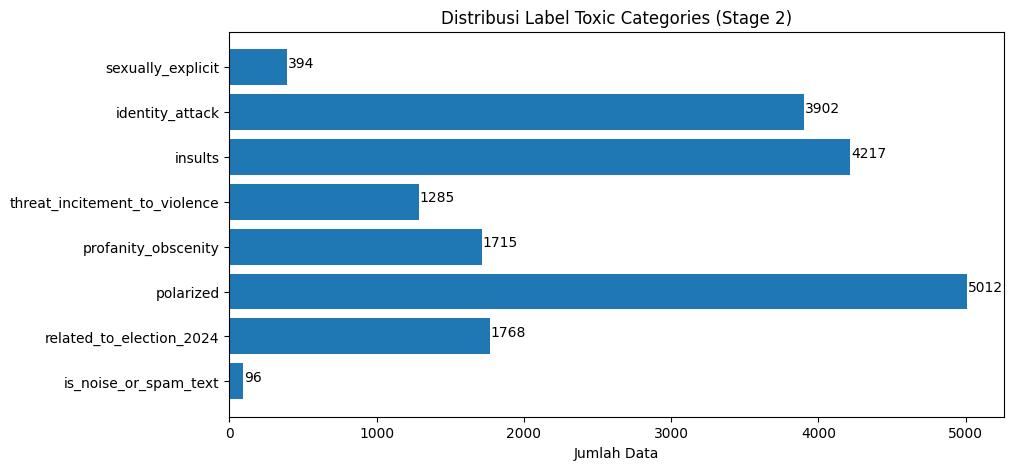

In [ ]:
import matplotlib.pyplot as plt

labels = list(label_counts.keys())
values = list(label_counts.values())

plt.figure(figsize=(10,5))

plt.barh(labels, values)

plt.title(
    "Distribusi Label Toxic Categories (Stage 2)"
)

plt.xlabel("Jumlah Data")

for i, v in enumerate(values):
    plt.text(v + 5, i, str(v))

plt.show()

In [ ]:
total_toxic_samples = len(stage2_df)

for label, count in label_counts.items():

    percentage = (
        count / total_toxic_samples
    ) * 100

    print(
        f"{label}: "
        f"{count} "
        f"({percentage:.2f}%)"
    )

is_noise_or_spam_text: 96 (1.03%)
related_to_election_2024: 1768 (19.04%)
polarized: 5012 (53.97%)
profanity_obscenity: 1715 (18.47%)
threat_incitement_to_violence: 1285 (13.84%)
insults: 4217 (45.41%)
identity_attack: 3902 (42.02%)
sexually_explicit: 394 (4.24%)


In [ ]:
from sklearn.preprocessing import LabelEncoder

df_temp2 = stage2_df.copy()

for col in annotator_cols:
    df_temp2[col] = df_temp2[col].astype(str)
    df_temp2[col] = LabelEncoder().fit_transform(df_temp2[col])

df_temp2

,text_id,annotator_id,text,initial_paragraph,topic,is_noise_or_spam_text,related_to_election_2024,toxicity,polarized,profanity_obscenity,...,religion,disability,lgbt,gender,age,domisili,pendidikan terakhir,status pekerjaan,president vote leaning,text_length
4,1-100,7,Gini aja deh @KPU_ID usul aja nih. Gimana kalo...,None,Disabilitas,0,1,1,0,0,...,3,1,0,0,6,12,3,0,1,39
26,1-101,7,"Apakah kita harus di pimpin oleh orang yg,waki...",None,Disabilitas,0,1,1,0,0,...,3,1,0,0,6,12,3,0,1,15
37,1-1014,18,Video Wanita Muslim Memaksa Wanita Hindu untuk...,"""Wanita Islam melecehkan seorang wanita Hindu ...",UNKNOWN,0,0,1,1,0,...,2,1,0,1,10,5,2,3,2,13
38,1-1015,10,Pesan Berantai “RENCANA BUSUK PEMBUNUHAN MASSA...,"NARASI: “JAGA² SAJA,JIKA DOKTER² MAU SUNTIK KI...",Tionghoa,0,1,1,1,0,...,1,0,0,0,1,16,4,2,3,12
39,1-1015,18,Pesan Berantai “RENCANA BUSUK PEMBUNUHAN MASSA...,"NARASI: “JAGA² SAJA,JIKA DOKTER² MAU SUNTIK KI...",Tionghoa,0,0,1,1,0,...,2,1,0,1,10,5,2,3,2,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53594,4-942,19,@Heraloebss Usir Rohingya dari Aceh dan dari s...,None,Rohingya,0,0,1,1,0,...,6,0,0,0,13,4,2,0,2,22
53599,4-947,19,Bismillah... Semoga orang yang mati-matian mem...,None,Syiah,0,0,1,1,0,...,6,0,0,0,13,4,2,0,2,33
53617,4-961,19,"Gila ya , kalau umat bersatu habis juga itu ge...",None,"LGBTQ+, Jewish, Disabilitas",0,0,1,1,0,...,6,0,0,0,13,4,2,0,2,14
53618,4-961,18,"Gila ya , kalau umat bersatu habis juga itu ge...",None,"LGBTQ+, Jewish, Disabilitas",0,0,1,1,0,...,2,1,0,1,10,5,2,3,2,14


In [ ]:
corr = df_temp2[LABEL_COLS + annotator_cols].corr()

# ambil hanya hubungan metadata → label
corr_subset = corr.loc[LABEL_COLS, annotator_cols]

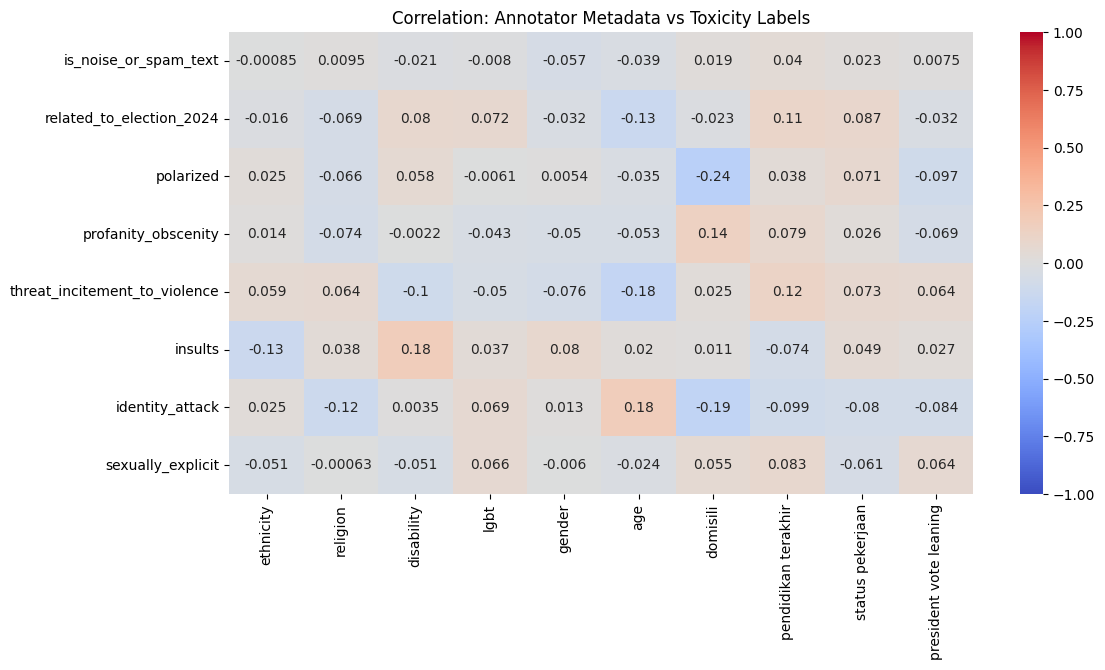

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.heatmap(
    corr_subset,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation: Annotator Metadata vs Toxicity Labels")
plt.show()